# Treinamento de Árvores de Decisão e Florestas
Este notebook aplica algoritmos de árvore de decisão em dois datasets processados.

- Tabela A: `coffee_classificado.csv` contém apenas variáveis de produção e colunas categóricas, sem notas sensoriais.
- Tabela B: `coffee_classificado_sensoriais.csv` inclui as mesmas colunas de produção mais atributos sensoriais.

O notebook usa:
- `DecisionTreeClassifier` para testar diferentes profundidades e parâmetros com Grid Search.
- `RandomForestClassifier` para comparar o desempenho de uma floresta de árvores.

# Arvore de decisão com tabela sem notas sensoriais

In [5]:
# ======================================================
# Lista para guardar os resultados de todos os modelos
# treinados neste notebook, usada no gráfico comparativo final
# ======================================================
resultados_modelos = []


In [6]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# =====================================================
# 1. Carregamento
# =====================================================

df = pd.read_csv("../data/processed/coffee_classificado.csv")

# =====================================================
# 2. Features
# =====================================================

colunas_numericas = [
    "Moisture",
    "Category_One_Defects",
    "Category_Two_Defects",
    "Quakers",
    "Altitude"
]

colunas_categoricas = [
    "Variety",
    "Processing_Method",
    "Country_of_Origin",
    "Color"
]

X = df[colunas_numericas + colunas_categoricas]
y = df["Classe"]

# =====================================================
# 3. One-Hot Encoding
# =====================================================

X = pd.get_dummies(
    X,
    columns=colunas_categoricas,
    drop_first=True
)

print("Shape após encoding:", X.shape)

# =====================================================
# 4. Train/Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# 5. Grid Search
# =====================================================

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# =====================================================
# 6. Melhores parâmetros
# =====================================================

print("\n========== MELHOR CONFIGURAÇÃO ==========")
print(grid.best_params_)

print("\nMelhor F1 (Cross Validation):")
print(round(grid.best_score_, 4))

# =====================================================
# 7. Avaliação no conjunto de teste
# =====================================================

melhor_arvore = grid.best_estimator_

y_pred = melhor_arvore.predict(X_test)

print("\n========== RESULTADOS ==========")

print("Accuracy:")
print(round(accuracy_score(y_test, y_pred), 4))

print("\nF1 Macro:")
print(round(float(f1_score(y_test, y_pred, average="macro")), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=["Tradicional", "Superior", "Gourmet"]
    )
)

# =====================================================
# 8. Importância das Features
# =====================================================

importancias = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": melhor_arvore.feature_importances_
})

importancias = (
    importancias
    .sort_values("Importancia", ascending=False)
)

print("\n========== TOP 20 FEATURES ==========")
print(importancias.head(20).to_string(index=False))

Shape após encoding: (1506, 57)
Fitting 5 folds for each of 384 candidates, totalling 1920 fits

========== MELHOR CONFIGURAÇÃO ==========
{'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Melhor F1 (Cross Validation):
0.4964

========== RESULTADOS ==========
Accuracy:
0.4338

F1 Macro:
0.4349

Classification Report:
              precision    recall  f1-score   support

     Gourmet       0.42      0.54      0.47        70
    Superior       0.47      0.43      0.45       127
 Tradicional       0.40      0.36      0.38       105

    accuracy                           0.43       302
   macro avg       0.43      0.45      0.43       302
weighted avg       0.44      0.43      0.43       302


Matriz de Confusão:
[[38 44 23]
 [42 55 30]
 [15 17 38]]

========== TOP 20 FEATURES ==========
                       Feature  Importancia
                      Altitude     0.200665
                      Moisture     0.175981
       

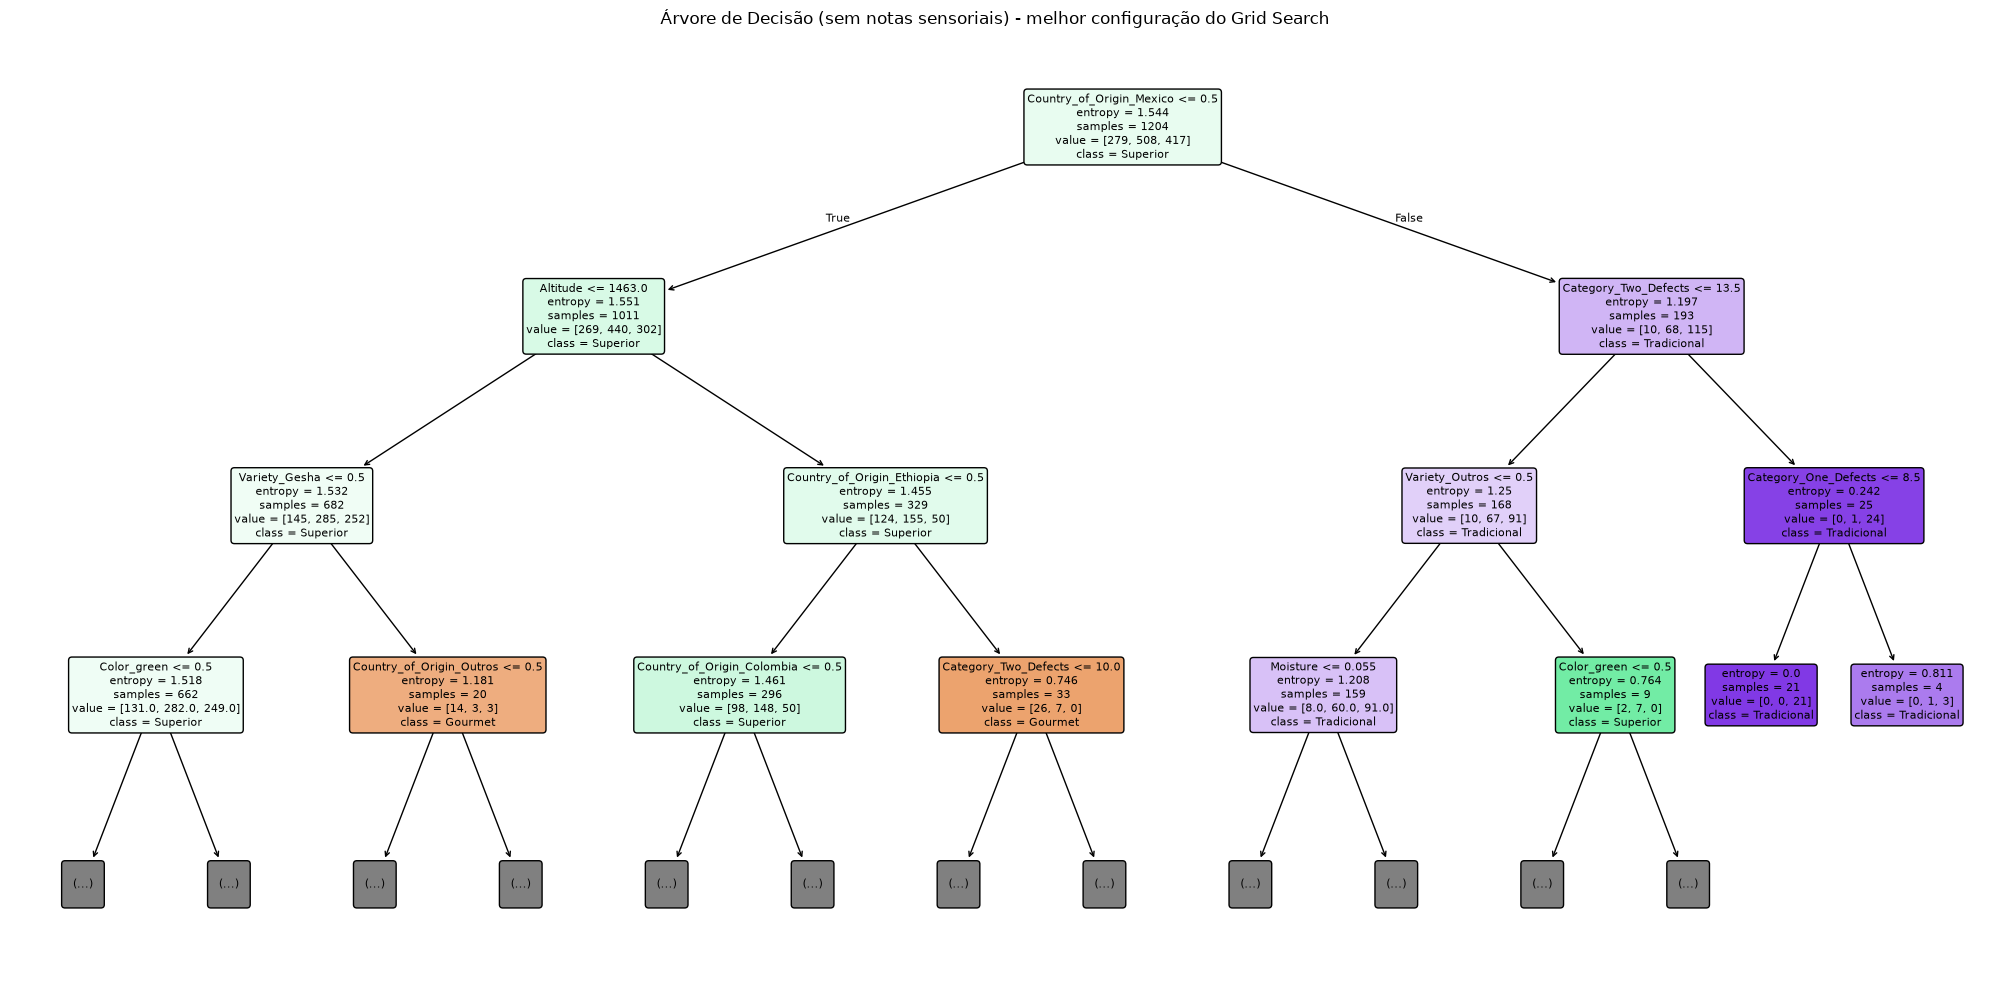

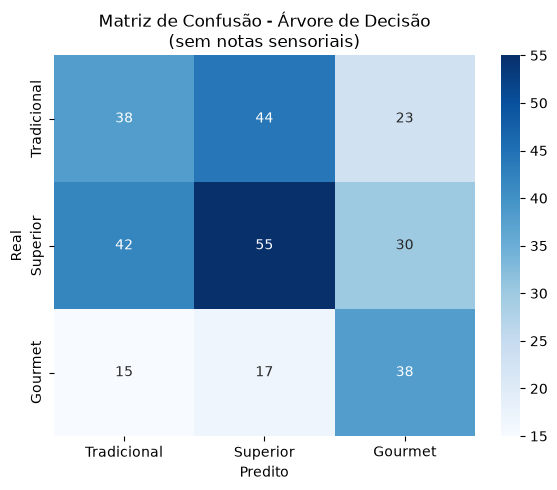

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

labels_classe = ['Tradicional', 'Superior', 'Gourmet']

# ======================================================
# Visualização da árvore de decisão (sem notas sensoriais)
# limitada a 3 níveis de profundidade só para leitura do gráfico
# ======================================================
plt.figure(figsize=(20, 10))
plot_tree(
    melhor_arvore,
    feature_names=X.columns,
    class_names=melhor_arvore.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Árvore de Decisão (sem notas sensoriais) - melhor configuração do Grid Search')
plt.tight_layout()
plt.savefig('../images/arvore_decisao.png', dpi=150)
plt.show()

# ======================================================
# Matriz de confusão da árvore de decisão (sem notas sensoriais)
# ======================================================
cm_arvore = confusion_matrix(y_test, y_pred, labels=labels_classe)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_arvore, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_classe, yticklabels=labels_classe
)
plt.title('Matriz de Confusão - Árvore de Decisão\n(sem notas sensoriais)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../images/matriz_confusao_arvore.png', dpi=150)
plt.show()

# Guardar resultado para comparação final
resultados_modelos.append({
    'Modelo': 'Árvore de Decisão',
    'Tabela': 'Sem sensorial',
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1_Macro': float(f1_score(y_test, y_pred, average='macro'))
})


# Random forest com tabela sem notas sensoriais

In [8]:
# random forest com 

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Macro:", f1_score(y_test, y_pred_rf, average='macro'))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.4867549668874172
F1 Macro: 0.4825298158631492
              precision    recall  f1-score   support

     Gourmet       0.43      0.51      0.47        70
    Superior       0.49      0.35      0.41       127
 Tradicional       0.52      0.64      0.57       105

    accuracy                           0.49       302
   macro avg       0.48      0.50      0.48       302
weighted avg       0.49      0.49      0.48       302



In [10]:
# Guardar resultado desta seção para comparação final
resultados_modelos.append({
    'Modelo': 'Random Forest',
    'Tabela': 'Sem sensorial',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1_Macro': float(f1_score(y_test, y_pred_rf, average='macro'))
})


# Arvore de decisão com tabela sensorial

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

df = pd.read_csv('../data/processed/coffee_classificado_sensoriais.csv')

colunas_numericas = ['Moisture', 'Category_One_Defects', 'Category_Two_Defects', 'Quakers', 'Altitude',
                     'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 
                     'Uniformity', 'Clean_Cup', 'Sweetness']
colunas_categoricas = ['Variety', 'Processing_Method', 'Country_of_Origin', 'Color']

X = df[colunas_numericas + colunas_categoricas]
y = df['Classe']

X_encoded = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)
print("Shape após encoding:", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Testando profundidades
resultados = []
for depth in [3, 4, 5, 6, 7, 8, 10, None]:
    arvore = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    arvore.fit(X_train, y_train)
    y_pred = arvore.predict(X_test)
    resultados.append({
        'max_depth': depth if depth else 'Sem limite',
        'Acc_Treino': round(arvore.score(X_train, y_train), 4),
        'Acc_Teste': round(arvore.score(X_test, y_test), 4),
        'F1_Macro': round(float(f1_score(y_test, y_pred, average='macro')), 4)
    })
print(pd.DataFrame(resultados).to_string(index=False))

# Modelo final (max_depth=5)
arvore_final = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
arvore_final.fit(X_train, y_train)
y_pred_final = arvore_final.predict(X_test)

print("\nAcurácia:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final, labels=['Tradicional','Superior','Gourmet']))

# Importância das features
importancias = pd.Series(arvore_final.feature_importances_, index=X_train.columns)
print("\nTop 10 features mais importantes:")
print(importancias.sort_values(ascending=False).head(10))

Shape após encoding: (1508, 121)
 max_depth  Acc_Treino  Acc_Teste  F1_Macro
         3      0.8201     0.7914    0.7907
         4      0.8474     0.8013    0.7997
         5      0.8864     0.8245    0.8224
         6      0.9071     0.8377    0.8374
         7      0.9328     0.8510    0.8514
         8      0.9502     0.8411    0.8419
        10      0.9718     0.8411    0.8425
Sem limite      1.0000     0.8543    0.8555

Acurácia: 0.8245033112582781
              precision    recall  f1-score   support

     Gourmet       0.82      0.84      0.83        70
    Superior       0.74      0.79      0.76       103
 Tradicional       0.91      0.84      0.88       129

    accuracy                           0.82       302
   macro avg       0.82      0.82      0.82       302
weighted avg       0.83      0.82      0.83       302

[[109  18   2]
 [ 11  81  11]
 [  0  11  59]]

Top 10 features mais importantes:
Aftertaste                   0.378398
Balance                      0.331589
Fla

In [12]:
# Guardar resultado desta seção para comparação final
resultados_modelos.append({
    'Modelo': 'Árvore de Decisão',
    'Tabela': 'Com sensorial',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'F1_Macro': float(f1_score(y_test, y_pred_final, average='macro'))
})


# Random forest com tabela sensorial

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Macro:", f1_score(y_test, y_pred_rf, average='macro'))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf, labels=['Tradicional','Superior','Gourmet']))

Accuracy: 0.8774834437086093
F1 Macro: 0.8760615471763105
              precision    recall  f1-score   support

     Gourmet       0.87      0.89      0.88        70
    Superior       0.81      0.87      0.84       103
 Tradicional       0.94      0.88      0.91       129

    accuracy                           0.88       302
   macro avg       0.88      0.88      0.88       302
weighted avg       0.88      0.88      0.88       302

[[113  13   3]
 [  7  90   6]
 [  0   8  62]]


# Comparação final entre os modelos

           Modelo        Tabela  Accuracy  F1_Macro
Árvore de Decisão Sem sensorial  0.433775  0.434908
    Random Forest Sem sensorial  0.486755  0.482530
Árvore de Decisão Com sensorial  0.824503  0.822350
    Random Forest Com sensorial  0.877483  0.876062


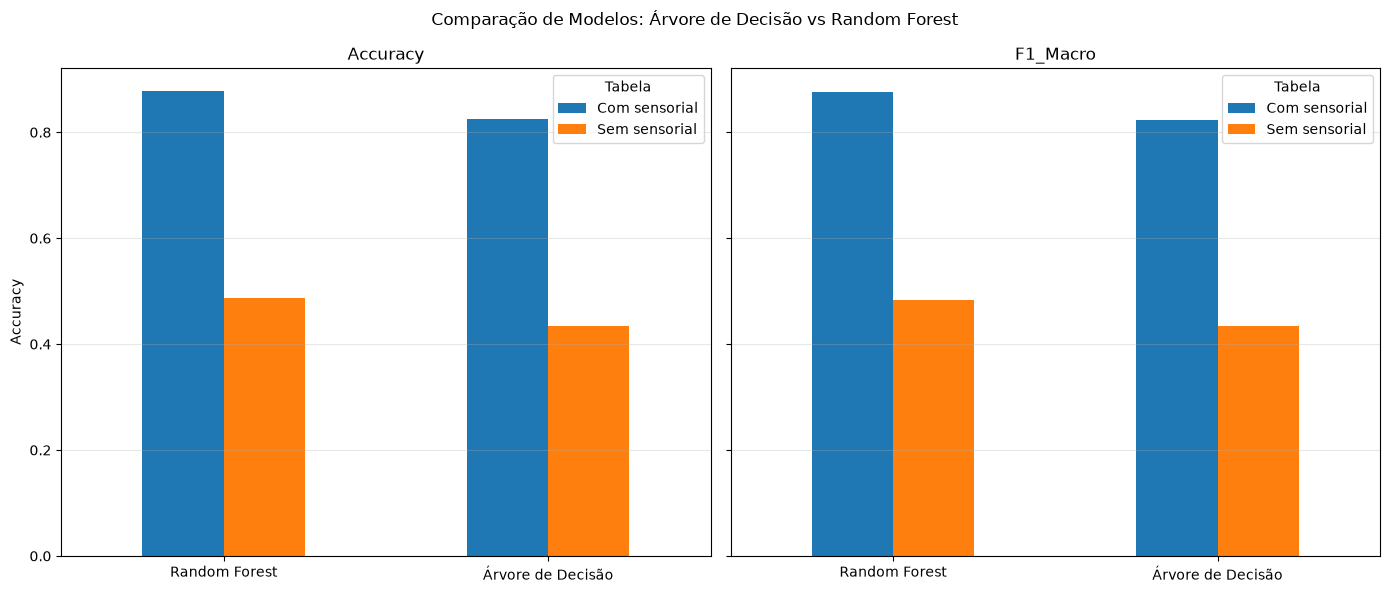

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Guardar resultado desta última seção (Random Forest com sensorial)
resultados_modelos.append({
    'Modelo': 'Random Forest',
    'Tabela': 'Com sensorial',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1_Macro': float(f1_score(y_test, y_pred_rf, average='macro'))
})

comparacao_df = pd.DataFrame(resultados_modelos)
print(comparacao_df.to_string(index=False))

# ======================================================
# Gráfico de barras comparando Accuracy e F1 Macro
# de todos os modelos treinados, nas duas tabelas
# ======================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

metricas = ['Accuracy', 'F1_Macro']
for metrica, ax in zip(metricas, axes):
    pivot = comparacao_df.pivot(index='Modelo', columns='Tabela', values=metrica)
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(metrica)
    ax.set_ylabel(metrica if metrica == 'Accuracy' else 'F1 Macro')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Tabela')

plt.suptitle('Comparação de Modelos: Árvore de Decisão vs Random Forest')
plt.tight_layout()
plt.savefig('../images/comparação_modelos.png', dpi=150)
plt.show()
